# CREDIT RISK MODEL I

Dataset = https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data

Este conjunto de datos clasifica a las personas descritas por un conjunto de atributos como riesgos crediticios buenos o malos.

## SECCION 1

In [648]:
import pandas as pd
import numpy as np


In [649]:
pip install kagglehub

In [650]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kabure/german-credit-data-with-risk")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'german-credit-data-with-risk' dataset.
Path to dataset files: /kaggle/input/german-credit-data-with-risk


In [651]:
import os

print(os.listdir(path))

df = pd.read_csv(os.path.join(path, "german_credit_data.csv"), index_col =0)
df.head()

['german_credit_data.csv']


,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


Age - Edad

Sex - Sexo

Job - Trabajo : [0 -unskilled and non-resident  , 1 - unskilled and resident , 2- skilled, , 3 - highly skilled]

saving accounts -  nivel en cuenta de ahorros : [ little, moderate, quite rich, rich]

checking accounts - nivel en cuenta corriente : [ little, moderate, rich]

housing - Vivienda : [ own, rent , free]

credit amount  - monto de crédito

duration - duracion del crédito en meses

purpose - propósito del crédito : [ car, furniture/equipment, radio/TV, domestic appliances, repairs, education, business, vacation/others]

Risk- riesgo de crédito : [ bueno, malo]

In [652]:
df.shape
# esperamos 1000 filas

(1000, 10)

In [653]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Age               1000 non-null   int64 
 1   Sex               1000 non-null   object
 2   Job               1000 non-null   int64 
 3   Housing           1000 non-null   object
 4   Saving accounts   817 non-null    object
 5   Checking account  606 non-null    object
 6   Credit amount     1000 non-null   int64 
 7   Duration          1000 non-null   int64 
 8   Purpose           1000 non-null   object
 9   Risk              1000 non-null   object
dtypes: int64(4), object(6)
memory usage: 85.9+ KB


In [654]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


### Duplicados

In [655]:
duplicados = df[df.duplicated()]
duplicados

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk


### Nulos


In [656]:
# columans con nulos
df.isnull().sum()

,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,183
Checking account,394
Credit amount,0
Duration,0
Purpose,0
Risk,0


In [657]:
# columnas con algun valor nulo
nulos = df[df.isnull().any(axis=1)] # axis 1 -> opera columa x columna
nulos

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
2,49,male,1,own,little,NaN,2096,12,education,good
5,35,male,1,free,NaN,NaN,9055,36,education,good
6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment,good
8,61,male,1,own,rich,NaN,3059,12,radio/TV,good
...,...,...,...,...,...,...,...,...,...,...
991,34,male,1,own,moderate,NaN,1569,15,radio/TV,good
992,23,male,1,rent,NaN,little,1936,18,radio/TV,good
994,50,male,2,own,NaN,NaN,2390,12,car,good
995,31,female,1,own,little,NaN,1736,12,furniture/equipment,good


In [658]:
# OPCIÓN 1 - eliminamos nulos
df_sin_nulos = df.dropna(axis = 0) # hacia abajo - filas
df_sin_nulos

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
7,35,male,3,rent,little,moderate,6948,36,car,good
9,28,male,3,own,little,moderate,5234,30,car,bad
...,...,...,...,...,...,...,...,...,...,...
989,48,male,1,own,little,moderate,1743,24,radio/TV,good
993,30,male,3,own,little,little,3959,36,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


<Axes: >

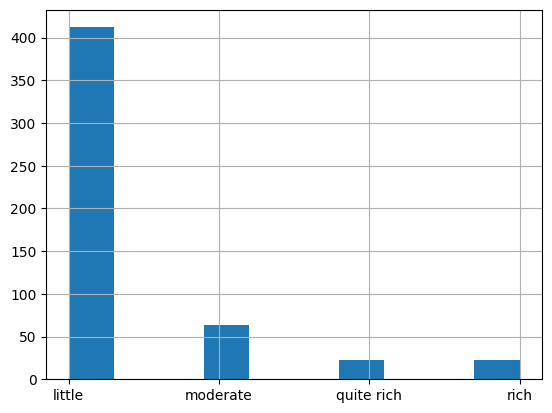

In [659]:
# OPCIÓN  2 - Reemplazar por la moda
df_sin_nulos["Saving accounts"].hist()


In [660]:
df_sin_nulos["Saving accounts"].describe()


,Saving accounts
count,522
unique,4
top,little
freq,412


In [661]:
# cuanto representa del total
(412/522) * 100   # > 70%

78.9272030651341

In [662]:
df_sin_nulos.groupby('Job')['Saving accounts'].agg(lambda x: x.mode()[0] if not x.mode().empty else None)

,Saving accounts
Job,
0,little
1,little
2,little
3,little


In [663]:
df_sin_nulos.groupby('Housing')['Saving accounts'].agg(lambda x: x.mode()[0] if not x.mode().empty else None)

,Saving accounts
Housing,
free,little
own,little
rent,little


In [664]:
df["Saving accounts"] = df["Saving accounts"].fillna(df_sin_nulos["Saving accounts"].mode()[0])

<Axes: >

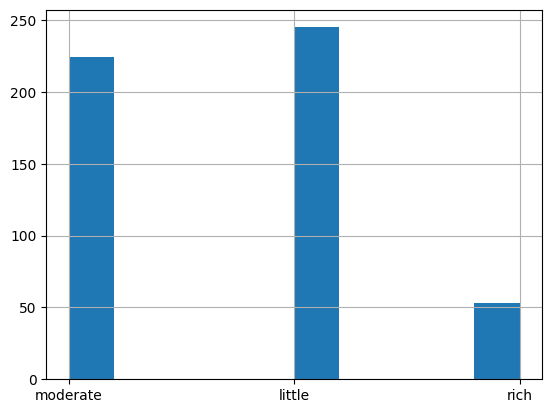

In [665]:
df_sin_nulos["Checking account"].hist()

In [666]:
df_sin_nulos["Checking account"].describe()


,Checking account
count,522
unique,3
top,little
freq,245


In [667]:
# cuanto representa del total
(245/522) * 100 # ok

46.934865900383144

In [668]:
df["Checking account"] =  df["Checking account"].fillna(df_sin_nulos["Checking account"].mode()[0])

In [669]:
df

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,little,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,little,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,little,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,little,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


### Estadísticos y distribución

#### Númericos

In [670]:
# numerico
df[['Age','Credit amount','Duration']].describe()


,Age,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000
mean,35.546000,3271.258000,20.903000
std,11.375469,2822.736876,12.058814
min,19.000000,250.000000,4.000000
25%,27.000000,1365.500000,12.000000
50%,33.000000,2319.500000,18.000000
75%,42.000000,3972.250000,24.000000
max,75.000000,18424.000000,72.000000


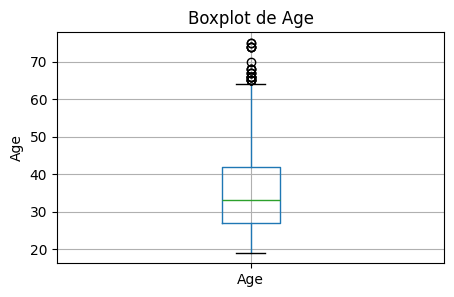

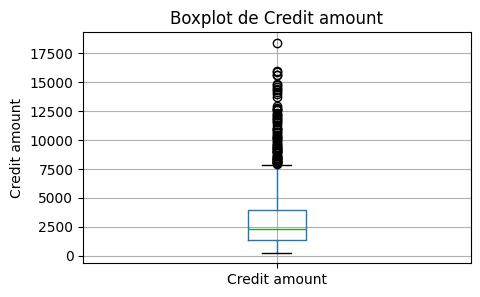

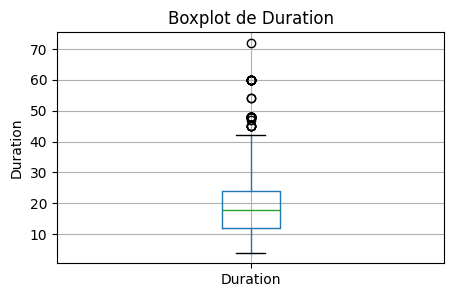

In [671]:
import matplotlib.pyplot as plt

num_cols = ['Age','Credit amount','Duration']

for col in num_cols:
    plt.figure(figsize=(5,3))
    df.boxplot(column=col)
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
    plt.show()

In [672]:
"""from sklearn.preprocessing import StandardScaler

scaled = StandardScaler().fit_transform(df[num_cols])
scaled_df = pd.DataFrame(scaled, columns=num_cols)

plt.figure(figsize=(8,6))
scaled_df.boxplot()
plt.title('Boxplots de variables numéricas (escaladas)')
plt.show()"""

"from sklearn.preprocessing import StandardScaler\n\nscaled = StandardScaler().fit_transform(df[num_cols])\nscaled_df = pd.DataFrame(scaled, columns=num_cols)\n\nplt.figure(figsize=(8,6))\nscaled_df.boxplot()\nplt.title('Boxplots de variables numéricas (escaladas)')\nplt.show()"

In [673]:
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)][col]
    print(f"{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.2f}%)")
    print(f"Valores fuera de rango: min={outliers.min()}, max={outliers.max()}")
    print("-----")


Age: 23 outliers (2.30%)
Valores fuera de rango: min=65, max=75
-----
Credit amount: 72 outliers (7.20%)
Valores fuera de rango: min=7966, max=18424
-----
Duration: 70 outliers (7.00%)
Valores fuera de rango: min=45, max=72
-----


<Figure size 500x300 with 0 Axes>

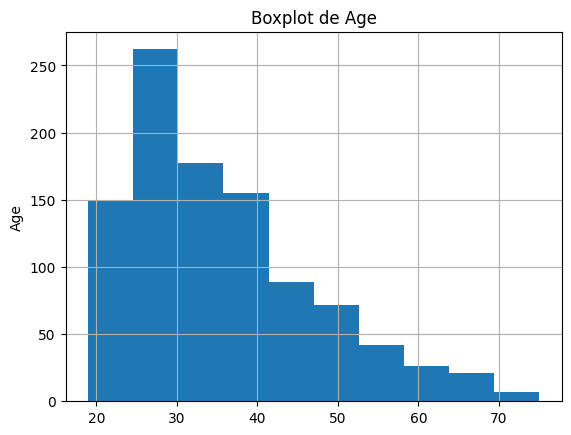

<Figure size 500x300 with 0 Axes>

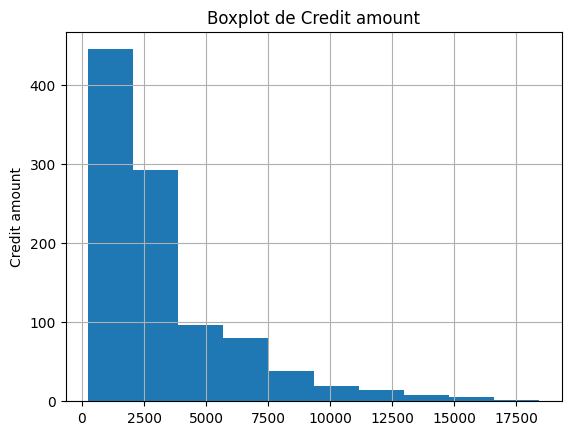

<Figure size 500x300 with 0 Axes>

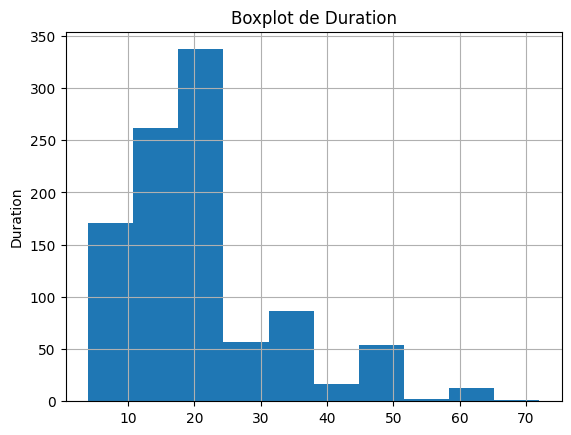

In [674]:
import matplotlib.pyplot as plt

for col in num_cols:
    plt.figure(figsize=(5,3))
    df.hist(column=col)
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
    plt.show()

**Conclusion**

Age - Ok

Credit amount - Desbalanceado

Duration - Desbalanceado

#### Corrección desbalanceo de datos

In [675]:
df["Credit amount"] = np.log1p(df["Credit amount"])
df["Duration"] = np.log1p(df["Duration"])

<Figure size 500x300 with 0 Axes>

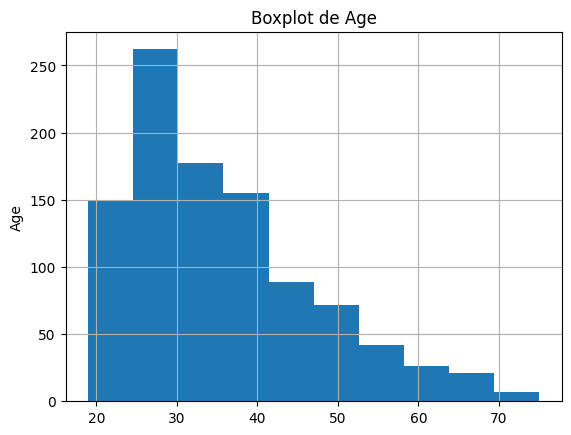

<Figure size 500x300 with 0 Axes>

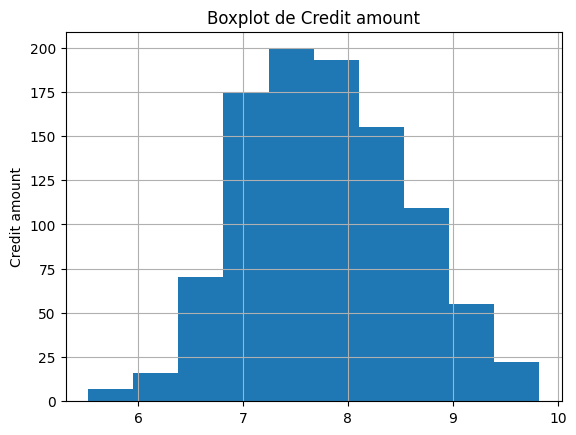

<Figure size 500x300 with 0 Axes>

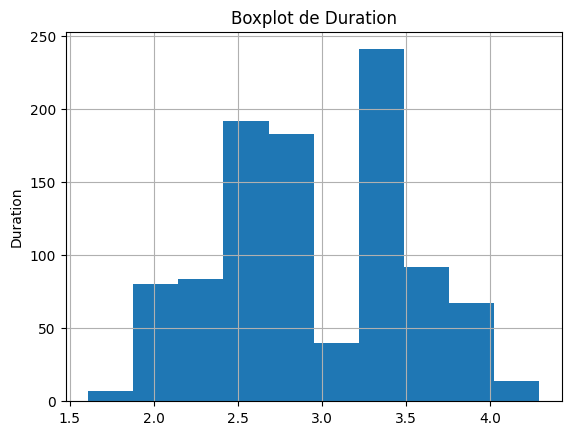

In [676]:
for col in num_cols:
    plt.figure(figsize=(5,3))
    df.hist(column=col)
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)
    plt.show()

In [677]:
df[['Age','Credit amount','Duration']].describe()

,Age,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000
mean,35.546000,7.789244,2.940942
std,11.375469,0.776074,0.546377
min,19.000000,5.525453,1.609438
25%,27.000000,7.220008,2.564949
50%,33.000000,7.749538,2.944439
75%,42.000000,8.287340,3.218876
max,75.000000,9.821464,4.290459


#### Categóricos

In [678]:
# categorico
for col in ['Sex','Job','Saving accounts','Checking account','Housing','Purpose','Risk']:
    print(df[col].value_counts(normalize=True)*100)

Sex
male      69.0
female    31.0
Name: proportion, dtype: float64
Job
2    63.0
1    20.0
3    14.8
0     2.2
Name: proportion, dtype: float64
Saving accounts
little        78.6
moderate      10.3
quite rich     6.3
rich           4.8
Name: proportion, dtype: float64
Checking account
little      66.8
moderate    26.9
rich         6.3
Name: proportion, dtype: float64
Housing
own     71.3
rent    17.9
free    10.8
Name: proportion, dtype: float64
Purpose
car                    33.7
radio/TV               28.0
furniture/equipment    18.1
business                9.7
education               5.9
repairs                 2.2
domestic appliances     1.2
vacation/others         1.2
Name: proportion, dtype: float64
Risk
good    70.0
bad     30.0
Name: proportion, dtype: float64


/tmp/ipython-input-3154908018.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="pastel")
/tmp/ipython-input-3154908018.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="pastel")
/tmp/ipython-input-3154908018.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="pastel")
/tmp/ipython-input-3154908018.py:10: FutureWarning: 

Passing `palette` without as

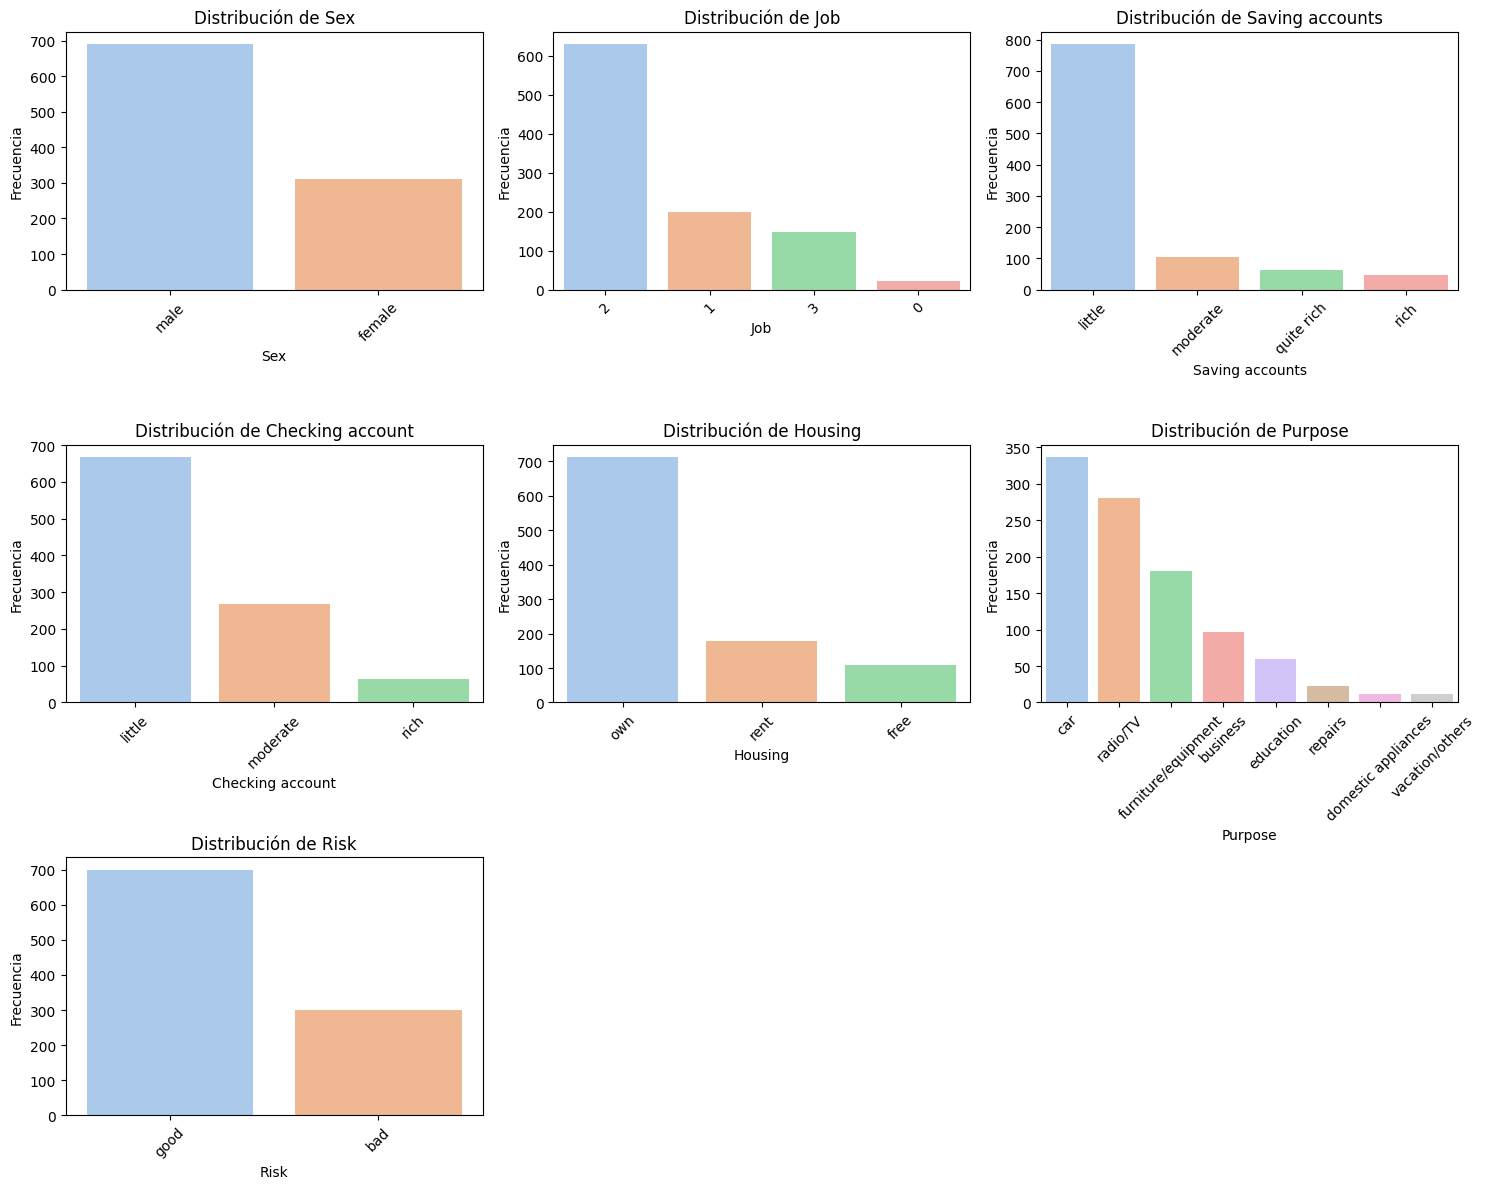

In [679]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_cols = ['Sex','Job','Saving accounts','Checking account','Housing','Purpose','Risk']

plt.figure(figsize=(15, 12))

for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index, palette="pastel")
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()


#### Correlaciones

In [680]:
# correlaciones
df.corr(numeric_only=True)

,Age,Job,Credit amount,Duration
Age,1.000000,0.015673,0.011702,-0.057229
Job,0.015673,1.000000,0.304628,0.220745
Credit amount,0.011702,0.304628,1.000000,0.625916
Duration,-0.057229,0.220745,0.625916,1.000000


## SECCION 2

In [681]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier


# SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, make_scorer
from sklearn.model_selection import cross_val_score, StratifiedKFold



In [682]:
# Codificamos Risk: good=0, bad=1
df['Risk'] = df['Risk'].map({'good':0, 'bad':1})


In [683]:
numeric_features = ['Age','Credit amount','Duration']
categorical_features = ['Sex','Job','Saving accounts','Checking account','Housing','Purpose']

In [684]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ])


## SECCION 3

In [685]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier()
}


In [686]:
# variables predictoras y risk
X = df.drop("Risk", axis=1)
y = df["Risk"]

In [687]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [688]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [689]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

resultados = []

for nombre, modelo in modelos.items():
    pipe = ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42)),
        ('model', modelo)
    ])

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)


    y_proba = pipe.predict_proba(X_test)[:,1] if hasattr(pipe.named_steps['model'], "predict_proba") else None

    print(f"\n=== {nombre} ===")
    print(classification_report(y_test, y_pred))

    if y_proba is not None:
        auc = roc_auc_score(y_test, y_proba)
        print(f"ROC-AUC: {auc:.3f}")

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))



=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.76      0.61      0.67       140
           1       0.38      0.55      0.45        60

    accuracy                           0.59       200
   macro avg       0.57      0.58      0.56       200
weighted avg       0.64      0.59      0.61       200

ROC-AUC: 0.637
Confusion Matrix:
[[85 55]
 [27 33]]

=== Decision Tree ===
              precision    recall  f1-score   support

           0       0.72      0.63      0.67       140
           1       0.33      0.43      0.38        60

    accuracy                           0.57       200
   macro avg       0.53      0.53      0.52       200
weighted avg       0.60      0.57      0.58       200

ROC-AUC: 0.531
Confusion Matrix:
[[88 52]
 [34 26]]

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.77      0.83      0.80       140
           1       0.51      0.42      0.46        60

   

In [690]:
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

modelos_grid = {
    "Gradient Boosting": {
        "model": GradientBoostingClassifier(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.05, 0.1]
        }
    },
    "SVM": {
        "model": SVC(probability=True, random_state=42),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__kernel": ["rbf", "linear"],
            "model__gamma": ["scale", "auto"]
        }
    },
    "XGBoost": {
        "model": XGBClassifier(random_state=42, eval_metric="logloss"),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [3, 5],
            "model__learning_rate": [0.05, 0.1]
        }
    }
}

resultados_final = []

for nombre, info in modelos_grid.items():
    print(f"\n===== {nombre} =====")

    pipe = ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", info["model"])
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=info["params"],
        scoring="roc_auc",
        cv=5,
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    print("Mejores hiperparámetros:", grid.best_params_)

    y_pred = grid.predict(X_test)
    y_proba = grid.predict_proba(X_test)[:,1]

    print(classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_proba))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    resultados_final.append((nombre, roc_auc_score(y_test, y_proba)))

# Ranking final
resultados_df = pd.DataFrame(resultados_final, columns=["Modelo", "ROC-AUC"])
print("\nRanking de modelos por ROC-AUC final:")
print(resultados_df.sort_values(by="ROC-AUC", ascending=False))



===== Gradient Boosting =====
Mejores hiperparámetros: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 100}
              precision    recall  f1-score   support

           0       0.81      0.74      0.77       140
           1       0.49      0.58      0.53        60

    accuracy                           0.69       200
   macro avg       0.65      0.66      0.65       200
weighted avg       0.71      0.69      0.70       200

ROC-AUC: 0.6867857142857143
Confusion Matrix:
 [[104  36]
 [ 25  35]]

===== SVM =====
Mejores hiperparámetros: {'model__C': 0.1, 'model__gamma': 'scale', 'model__kernel': 'linear'}
              precision    recall  f1-score   support

           0       0.77      0.61      0.68       140
           1       0.38      0.57      0.46        60

    accuracy                           0.59       200
   macro avg       0.57      0.59      0.57       200
weighted avg       0.65      0.59      0.61       200

ROC-AUC: 0.656785714285714

## MODELO ELEGIDO: GRADIENT BOOSTING